the input is line in W/m2/sr to convert into W/m2/sr/um

use Ariel pixel resolution as input grid
compute total signal in detector
compute shape of signal
compute noise

have the signal dictated by the noise levels and reasonable integration time (~10min)

week line produce SNR>3 for 10 mins integration time
strong line produce SNR>300 for 10 min integration time

use more lines, make sure they not overlaps
1) simulate low to high SNR using also the zodi (planetary nebula)
2) then add a continuum that should be flat (galaxy)
3) more spectral lines but dominated by continuum

In [55]:
from astropy.table import QTable
import exosim.recipes as recipes
import numpy as np
import astropy.units as u
import os
import exosim.tasks.load as load
from exosim.utils.prepare_recipes import clean_config_files
from astropy.io import ascii

line_amplitude = 1e-6* u.W / (u.m**2 * u.sr)

def create_foreground(lines):

    foreground = QTable()
    wl_input = ascii.read("wavelengths.ecsv")["col0"] * u.um
    foreground['wavelength'] = wl_input
    foreground['bin_width'] = np.gradient(wl_input.value) * wl_input.unit
    foreground["radiance"] = np.zeros(len(foreground["wavelength"])) * u.W / (u.m**2 * u.sr * u.um)
    foreground["transmission"] = np.ones(len(foreground["wavelength"]))

    for line in lines:
        idx = np.argmin(np.abs(foreground['wavelength'] - line))
        foreground['radiance'][idx] += line_amplitude / foreground['bin_width'][idx]
    return foreground


lines = [2.2, 2.8, 3.3, 3.8, 4.7, 5.9, 6.9, 7.7] * u.um

foreground = create_foreground(lines)
foreground.write("foreground.ecsv", overwrite=True)

recipes.CreateFocalPlane("main.xml", "./test_common.h5")
recipes.CreateSubExposures(options_file="main.xml", input_file="./test_common.h5", output_file="./test_sub.h5")
recipes.CreateNDRs(options_file="main.xml", input_file="./test_sub.h5", output_file="./test_ndrs.h5")
os.remove("test_common.h5")
os.remove("test_sub.h5")

clean_config_files()
loadOption = load.LoadOptions()
config = loadOption(filename="main.xml")

config["sky"]["foregrounds"] ={"opticalElement": {"value": "zodiacal", "zodiacal_factor": 2.5, }}
for ch in config["payload"]["channel"]:
    config["payload"]["channel"][ch]["detector"]["dark_current"] = True
    config["payload"]["channel"][ch]["detector"]["read_noise"] = True
    

recipes.CreateFocalPlane(config, "./test_common.h5")
recipes.CreateSubExposures(options_file=config, input_file="./test_common.h5", output_file="./test_sub.h5")
recipes.CreateNDRs(options_file=config, input_file="./test_sub.h5", output_file="./test_ndrs_bkg.h5")
os.remove("test_common.h5")
os.remove("test_sub.h5")


2026-07-13T10:36:35 [graphics    ] 
 *    *    .  *    // *            .  *
     *  .  ..  *  //.     *      *        *    .
..    *  ___o |==//     .      *   *
        /\  \/  //|\   *  .  ..   *       *
       / /        | \  exosim 2.1.1.dev3
       ` `        '  '
 class_name=CreateFocalPlane package=exosim
2026-07-13T10:36:35 [info        ] -- RUN CONFIGURATION --------- class_name=RunConfigInit package=exosim
2026-07-13T10:36:35 [info        ] number of available cpus: 15   class_name=RunConfigInit package=exosim
2026-07-13T10:36:35 [info        ] number of used cpus: 1         class_name=RunConfigInit package=exosim
2026-07-13T10:36:35 [info        ] random seed: 1645330554        class_name=RunConfigInit package=exosim
2026-07-13T10:36:35 [info        ] chunk size (Mb): 2             class_name=RunConfigInit package=exosim
2026-07-13T10:36:35 [info        ] ------------------------------ class_name=RunConfigInit package=exosim
2026-07-13T10:36:35 [announcement] started        

/Users/spxlm4/micromamba/envs/py3.12/lib/python3.12/site-packages/astropy/units/quantity.py:676: RuntimeWarning: overflow encountered in expm1
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/spxlm4/micromamba/envs/py3.12/lib/python3.12/site-packages/astropy/units/quantity.py:676: RuntimeWarning: overflow encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


2026-07-13T10:36:35 [info        ] No sources defined, skipping focal plane population. class_name=Channel package=exosim
2026-07-13T10:36:35 [info        ] adding foreground to focal plane class_name=ForegroundsToFocalPlane package=exosim
2026-07-13T10:36:35 [info        ] AIRS-CH0 ended in: 00h00m00s   class_name=CreateFocalPlane package=exosim
2026-07-13T10:36:35 [announcement] channel AIRS-CH1 started       class_name=CreateFocalPlane package=exosim
2026-07-13T10:36:35 [info        ] parsing optical path           class_name=ParsePath package=exosim
2026-07-13T10:36:36 [info        ] creating focal plane           class_name=CreateFocalPlane package=exosim
2026-07-13T10:36:36 [info        ] No sources defined, skipping focal plane population. class_name=Channel package=exosim
2026-07-13T10:36:36 [info        ] adding foreground to focal plane class_name=ForegroundsToFocalPlane package=exosim


/Users/spxlm4/micromamba/envs/py3.12/lib/python3.12/site-packages/astropy/units/quantity.py:676: RuntimeWarning: overflow encountered in expm1
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/spxlm4/micromamba/envs/py3.12/lib/python3.12/site-packages/astropy/units/quantity.py:676: RuntimeWarning: overflow encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


2026-07-13T10:36:36 [info        ] AIRS-CH1 ended in: 00h00m00s   class_name=CreateFocalPlane package=exosim
2026-07-13T10:36:36 [info        ] recipe ended: 00h00m00s        class_name=CreateFocalPlane package=exosim
2026-07-13T10:36:36 [info        ] output ./test_common.h5 size: 26.244 Mbit class_name=CreateFocalPlane package=exosim
2026-07-13T10:36:36 [announcement] ended                          class_name=CreateFocalPlane package=exosim
2026-07-13T10:36:36 [graphics    ] 
* .   .  * *   .   .     ..     * .  . *   *  .
.###   *      .   *    .   *    ..        . .
#######   .  *       .            *      *
######### *   .     .   *    .       *     .
\#|#/###    .            //              .  *
.\|/###  *     .        //  *  .  ..   *       *
#)|(#      *   ___o |==// .      *   *    .  .
 )|( .   *    /\  \/  //|\  . *    .    *      .
 )|(         / /        | \ exosim 2.1.1.dev3
             ` `        '  '
 class_name=CreateSubExposures package=exosim
2026-07-13T10:36:36 [in

...

2026-07-13T10:36:37 [info        ] adding read noise              class_name=AddNormalReadNoise package=exosim


adding read noise:   0%|          | 0/1 [00:00<?, ?chunk/s]

2026-07-13T10:36:37 [info        ] merging groups                 class_name=MergeGroups package=exosim


merging groups:   0%|          | 0/1 [00:00<?, ?chunk/s]

2026-07-13T10:36:37 [info        ] Cleaning the output tree       class_name=CreateNDRs package=exosim
2026-07-13T10:36:37 [info        ] AIRS-CH1 completed.            class_name=CreateNDRs package=exosim
2026-07-13T10:36:37 [info        ] AIRS-CH1 ended in: 00h00m00s   class_name=CreateNDRs package=exosim
2026-07-13T10:36:37 [info        ] Refactoring output             class_name=CreateNDRs package=exosim
2026-07-13T10:36:37 [info        ] output ./test_ndrs_bkg.h5 size: 1.846 Mbit class_name=CreateNDRs package=exosim
2026-07-13T10:36:37 [info        ] recipe ended: 00h00m00s        class_name=CreateNDRs package=exosim
2026-07-13T10:36:37 [announcement] ended                          class_name=CreateNDRs package=exosim


manual centres provided, built regions: [{'center': np.int64(290), 'width': 60}, {'center': np.int64(214), 'width': 60}, {'center': np.int64(142), 'width': 60}, {'center': np.int64(56), 'width': 60}]
manual centres provided, built regions: [{'center': np.int64(100), 'width': 21}, {'center': np.int64(74), 'width': 21}, {'center': np.int64(47), 'width': 21}, {'center': np.int64(18), 'width': 21}]
Detected 0 lines in CH0 and 0 lines in CH1
CH0 widths: [60, 60, 60, 60]
CH1 widths: [21, 21, 21, 21]


left,right,top,bottom,width_px,area_px,raw_sum,raw_median,raw_std,bkg_per_pix,bkg_total,net_flux
int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64
260,319,0,63,60,3840,19640444.308575496,5200.6809621043485,644.2703095351279,156.86584606993426,602364.8489085475,19038079.45966695
184,243,0,63,60,3840,25172086.8285582,6664.18060397672,829.9640591974078,113.52360099566127,435930.62782333925,24736156.20073486
112,171,0,63,60,3840,27327524.318594854,7234.775044551638,899.7258408628991,72.4325220029946,278140.8844914993,27049383.434103355
26,85,0,63,60,3840,32109713.36130435,8509.275721090133,1074.8433785978568,43.98110895629848,168887.45839218615,31940825.902912162


left,right,top,bottom,width_px,area_px,raw_sum,raw_median,raw_std,bkg_per_pix,bkg_total,net_flux
int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64
90,110,0,63,21,1344,35617280.668558076,26445.485424775627,624.0265201001865,1998.8434032124037,2686445.5339174704,32930835.134640604
64,84,0,63,21,1344,51039597.176999584,38026.250237047345,761.65222880889,5111.004663114778,6869190.267226262,44170406.90977332
37,57,0,63,21,1344,60005001.73896323,44744.08744456358,288.0688318048203,7323.543982005034,9842843.111814765,50162158.627148464
8,28,0,63,21,1344,50241203.62449763,37640.602509114884,1096.5687408294255,5434.25383128891,7303637.1492522955,42937566.475245334


left,right,top,bottom,width_px,area_px,raw_sum,raw_median,raw_std,bkg_per_pix,bkg_total,net_flux
int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64
260,319,0,63,60,3840,1161657.1051970131,304.4170401421179,28.32996015286304,256.6597444269854,985573.418599624,176083.68659738917
184,243,0,63,60,3840,888578.926780937,231.5310917754528,22.86157163114937,234.40420818592582,900112.1594339552,-11533.232653018204
112,171,0,63,60,3840,728081.3974445009,189.49059695493338,15.791187873977657,192.84650467933187,740530.5779686344,-12449.180524133495
26,85,0,63,60,3840,651849.882813939,170.53535098226632,21.050721632301556,164.35017379230953,631104.6673624685,20745.21545147046


left,right,top,bottom,width_px,area_px,raw_sum,raw_median,raw_std,bkg_per_pix,bkg_total,net_flux
int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64
90,110,0,63,21,1344,2533902.7401085347,1821.337974667874,629.2810720772453,2009.0154723564758,2700116.7948471033,-166214.0547385686
64,84,0,63,21,1344,6942650.784358424,5206.344361546333,751.2791487890556,5079.893046052037,6827376.253893938,115274.53046448622
37,57,0,63,21,1344,10178070.458259474,7682.468874874194,251.95053090767564,7231.78157294138,9719514.434033215,458556.02422625944
8,28,0,63,21,1344,7850949.2138569215,6072.928787989062,1080.8629151026068,5324.946627290217,7156728.267078052,694220.9467788693


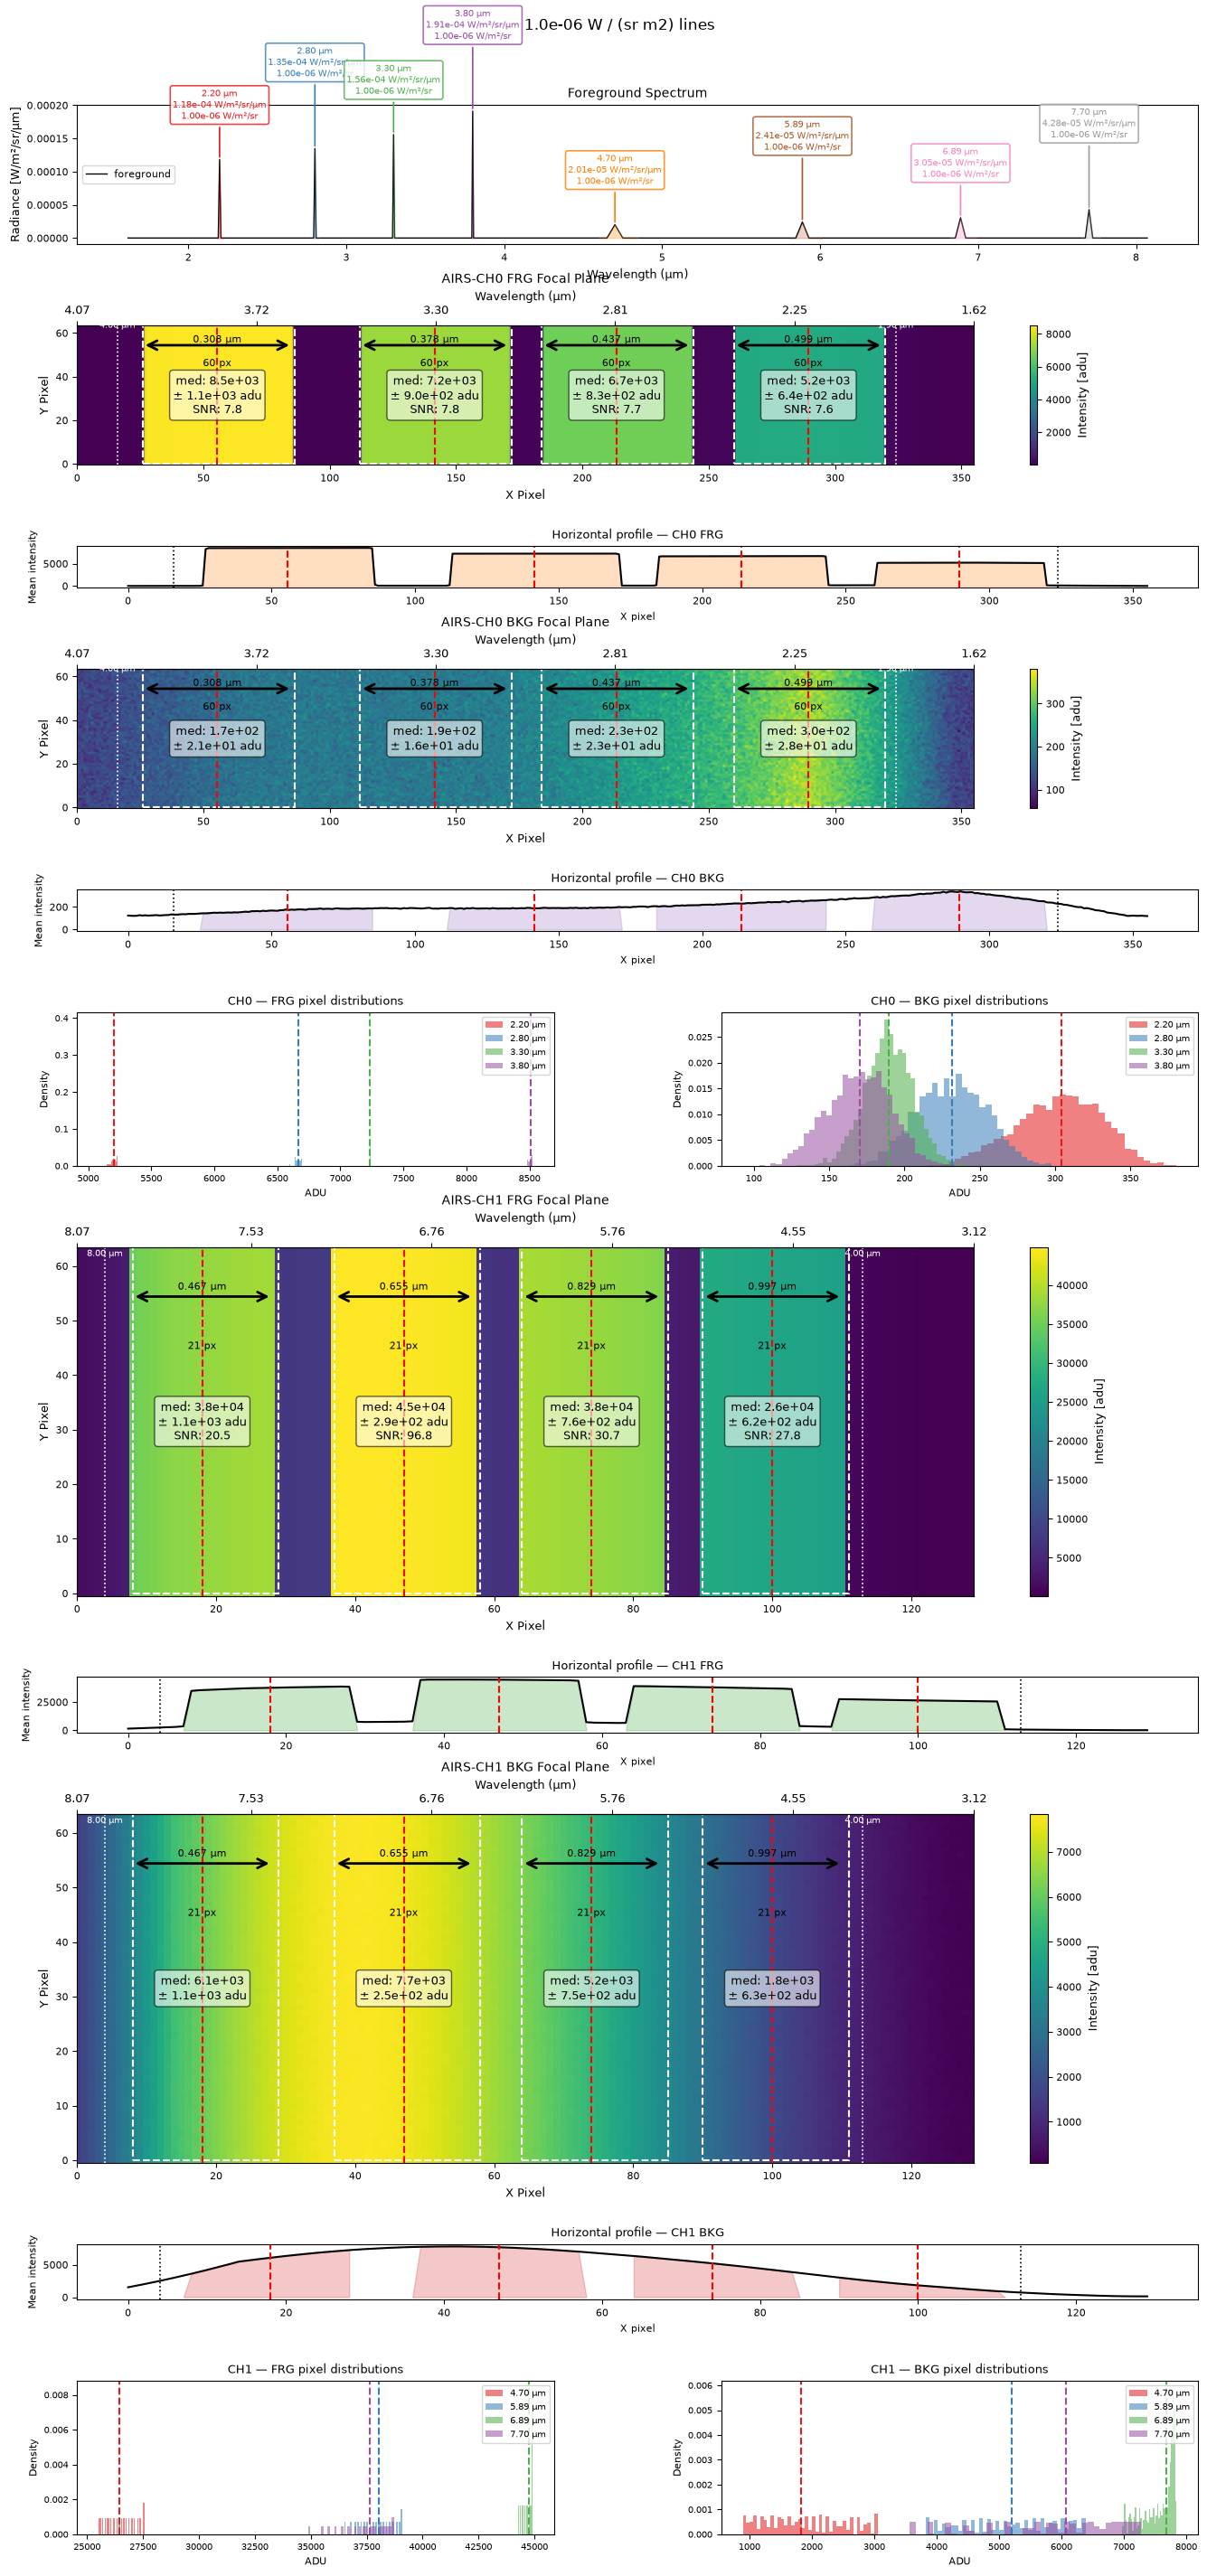

In [56]:
import sys
import h5py
import astropy.units as u
from astropy.io import ascii

# Clear any stale cached versions of the src modules so imports are always fresh
for _key in list(sys.modules.keys()):
    if _key == "src" or _key.startswith("src."):
        del sys.modules[_key]

import src.aperture_photometry as ap
import src.plot_single as plot_single
from src.line_detect import assign_lines_to_channels, detect_and_build_regions



# Optional manual wavelength limits (Quantity or float in µm) per channel.
manual_wl_min_ch0 = 1.9 * u.um
manual_wl_max_ch0 = 4 * u.um
manual_wl_min_ch1 = 4 * u.um
manual_wl_max_ch1 = 8 * u.um

# Manual widths in pixels (scalar applied to all detected lines, or list matching detected count)
manual_widths_ch0 = 60
manual_widths_ch1 = 21

# saturation limits in ADU
saturation_limit_ch0 = 85000
saturation_limit_ch1 = 50000



def compute_cds(input_file):
    with h5py.File(input_file, "r") as f:
        ds = f["channels"]["AIRS-CH0"]["NDRs"]
        wl_ch0 = ds["spectral"][()] * u.um
        units = ds["data_units"][()].decode()
        

        # cds_time_ch0 = (ds["time"][1:] + ds["time"][:-1]) / 2 *3600
        # cds_ch0 = np.diff(ds["data"][:], axis=0)#/cds_time_ch0[:, None, None]
        cds_ch0 = ds["data"][1]
        
        ds = f["channels"]["AIRS-CH1"]["NDRs"]
        wl_ch1 = ds["spectral"][()] * u.um
        # cds_time_ch1 = (ds["time"][1:] + ds["time"][:-1]) / 2 *3600
        # cds_ch1 = np.diff(ds["data"][:], axis=0)#/cds_time_ch1[:, None, None]
        cds_ch1 = ds["data"][1] #axis=0)#/cds_time_ch1[:, None, None]
        units = u.Unit(ds["data_units"][()].decode())#/u.s
        return  cds_ch0, wl_ch0, cds_ch1, wl_ch1, units

# ── 1. Read focal-plane data ────────────────────────────────────────────────
ch0_frg, wl_ch0, ch1_frg, wl_ch1, units = compute_cds("./test_ndrs.h5")

# ── 2. Read single foreground and auto-assign lines to channels ──────────────
foreground = ascii.read("foreground.ecsv")
foreground_ch0, foreground_ch1 = assign_lines_to_channels(foreground, wl_ch0, wl_ch1, buffer_pixels=1)

# ── 3. Build foreground-filtered search images and build regions ───────────

# Optional manual centres (pixel positions) — set lists to override detection
manual_centers_ch0 = [np.argmin(np.abs(wl_ch0 - line)) for line in lines if line >= manual_wl_min_ch0 and line <= manual_wl_max_ch0]
manual_centers_ch1 = [np.argmin(np.abs(wl_ch1 - line)) for line in lines if line >= manual_wl_min_ch1 and line <= manual_wl_max_ch1]

# Detect and build regions using the helper in src/line_detect (verbose mode)
regions_ch0, detected_ch0 = detect_and_build_regions(
    ch0_frg, wl_ch0, foreground_ch0,
    manual_wl_min=manual_wl_min_ch0, manual_wl_max=manual_wl_max_ch0,
    manual_widths=manual_widths_ch0, manual_centers=manual_centers_ch0,
    threshold_factor=0.05, fraction=0.1,
    verbose=True,
)

regions_ch1, detected_ch1 = detect_and_build_regions(
    ch1_frg, wl_ch1, foreground_ch1,
    manual_wl_min=manual_wl_min_ch1, manual_wl_max=manual_wl_max_ch1,
    manual_widths=manual_widths_ch1, manual_centers=manual_centers_ch1,
    threshold_factor=0.05, fraction=0.1,
    verbose=True,
)

print(f"Detected {len(detected_ch0)} lines in CH0 and {len(detected_ch1)} lines in CH1")
print("CH0 widths:", [r['width_px'] for r in regions_ch0])
print("CH1 widths:", [r['width_px'] for r in regions_ch1])

# ── 5. Build apertures ───────────────────────────────────────────────────────
metas_ch0, masks_ch0 = ap.build_segment_apertures(regions_ch0, *ch0_frg.shape, padding=0)
metas_ch1, masks_ch1 = ap.build_segment_apertures(regions_ch1, *ch1_frg.shape, padding=0)

# ── 6. Aperture photometry ───────────────────────────────────────────────────
def _to_qtable(phot, metas):
    t = QTable()
    for k in ["left", "right", "top", "bottom", "width_px", "area_px"]:
        t[k] = [m.get(k) for m in metas]
    for k in ["raw_sum", "raw_median", "raw_std", "bkg_per_pix", "bkg_total", "net_flux"]:
        t[k] = [r[k] for r in phot]
    return t

table_ch0 = _to_qtable(ap.aperture_photometry(ch0_frg, metas_ch0, masks_ch0), metas_ch0)
table_ch1 = _to_qtable(ap.aperture_photometry(ch1_frg, metas_ch1, masks_ch1), metas_ch1)
display(table_ch0)
display(table_ch1)

# ── 7. background aperture photometry ──────────────────────────────────────────────────────────────────
ch0_bkg, wl_ch0, ch1_bkg, wl_ch1, units = compute_cds("./test_ndrs_bkg.h5")

metas_ch0, masks_ch0 = ap.build_segment_apertures(regions_ch0, *ch0_bkg.shape, padding=0)
metas_ch1, masks_ch1 = ap.build_segment_apertures(regions_ch1, *ch1_bkg.shape, padding=0)

table_ch0_bkg = _to_qtable(ap.aperture_photometry(ch0_bkg, metas_ch0, masks_ch0), metas_ch0)
table_ch1_bkg = _to_qtable(ap.aperture_photometry(ch1_bkg, metas_ch1, masks_ch1), metas_ch1)
table_ch0_bkg.write("photometry_ch0_bkg.ecsv", overwrite=True)
table_ch1_bkg.write("photometry_ch1_bkg.ecsv", overwrite=True)
display(table_ch0_bkg)
display(table_ch1_bkg)

# ── 8. Compute SNR (real-life: median-based per-pixel statistic) ─────────────
# signal = median(FRG aperture) - median(BKG aperture)
# noise  = sqrt(std_FRG² + std_BKG²)
table_ch0["signal"] = table_ch0["raw_median"] - table_ch0_bkg["raw_median"]
table_ch1["signal"] = table_ch1["raw_median"] - table_ch1_bkg["raw_median"]
table_ch0["noise"]  = np.sqrt(table_ch0["raw_std"]**2 + table_ch0_bkg["raw_std"]**2)
table_ch1["noise"]  = np.sqrt(table_ch1["raw_std"]**2 + table_ch1_bkg["raw_std"]**2)
table_ch0["snr"]    = table_ch0["signal"] / table_ch0["noise"]
table_ch1["snr"]    = table_ch1["signal"] / table_ch1["noise"]

# propagate bkg_total for backward compatibility with plot
table_ch0["bkg_total"] = table_ch0_bkg["raw_median"]
table_ch1["bkg_total"] = table_ch1_bkg["raw_median"]

# ── 9. Plot ──────────────────────────────────────────────────────────────────
plot_single.plot(
    title=f"{line_amplitude:.1e} lines",
    ch0_frg=ch0_frg,        ch1_frg=ch1_frg,
    wl_ch0=wl_ch0,          wl_ch1=wl_ch1,
    foreground=foreground,
    search_ch0=None,  search_ch1=None,
    masks_ch0=masks_ch0,    masks_ch1=masks_ch1,
    table_ch0=table_ch0,    table_ch1=table_ch1,
    regions_ch0=regions_ch0, regions_ch1=regions_ch1,
    threshold_factor=0.05,
    units=units,
    manual_wl_min_ch0=manual_wl_min_ch0, manual_wl_max_ch0=manual_wl_max_ch0,
    manual_wl_min_ch1=manual_wl_min_ch1, manual_wl_max_ch1=manual_wl_max_ch1,
    ch0_bkg=ch0_bkg,        ch1_bkg=ch1_bkg,
    table_ch0_bkg=table_ch0_bkg, table_ch1_bkg=table_ch1_bkg,
    saturation_limit_ch0=saturation_limit_ch0, saturation_limit_ch1=saturation_limit_ch1,
)


In [58]:
wl_ch0 = wl_ch0[wl_ch0 < 4 * u.um]
wl_ch1 = wl_ch1[wl_ch1 >= 4 * u.um]
wl = np.concatenate([wl_ch0, wl_ch1])
wl.sort()
ascii.write([wl], "wavelengths.ecsv", overwrite=True)


another approach is FG-BNG/sqrt(std(fg-bkg)) use median and std
represent real life scenario
use 0.5% QE variation correction
